In [1]:
import csv
import json
from pathlib import Path
from solve_kis import solve_kis

from siglip_encoder import SiglipEncoder
from search_clip import SiglipRetriever 
from caption_retriever import CaptionRetriever
from paths import KIS_ROOT, MAPPING_DIR, OBJECTS_DIR, safe_filename_component


c:\Users\Khanh\miniconda3\envs\focusguard_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from bm25_retriever import BM25Retriever

In [3]:
encoder = SiglipEncoder()
retriever = SiglipRetriever()

print("SigLIP OK")

[*] Loading SigLIP on cpu...


Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 1147.32it/s]


[*] SigLIP loaded.
Connected to Milvus: clip_keyframes
SigLIP OK


In [4]:
print("[*] Đang khởi tạo Caption Retriever (toàn bộ dữ liệu)...")

try:
    caption_retriever = CaptionRetriever()
    
    # Thống kê nhanh số video có trong mapping để dễ kiểm tra dữ liệu.
    unique_videos = sorted(
        {item["video_id"] for item in caption_retriever.mapping}
    ) if caption_retriever.mapping else []

    print(
        f"[*] caption_retriever sẵn sàng: "
        f"{caption_retriever.index.ntotal} vectors, "
        f"{len(unique_videos)} videos"
    )

except (FileNotFoundError, ValueError, RuntimeError) as e:
    print(f"[Lỗi] Không tìm thấy dữ liệu caption/index/mapping: {e}")
    print(
        "    Hãy đảm bảo đã có file trong các thư mục:\n"
        "    - caption_generator/Lxx/*.json\n"
        "    - index/Lxx/*.index\n"
        "    - caption_mapping/Lxx/*.json"
    )
    raise

[*] Đang khởi tạo Caption Retriever (toàn bộ dữ liệu)...
[Caption] Loading SentenceTransformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2462.95it/s]


[Caption] Loaded 160793 caption vectors
[*] caption_retriever sẵn sàng: 160793 vectors, 774 videos


In [5]:
all_captions = caption_retriever.caption_data
print(f"[*] Đã thu thập được {len(all_captions)} frames caption để nạp vào BM25.")



[*] Đã thu thập được 160793 frames caption để nạp vào BM25.


In [6]:
from object_filter import ObjectMetadataLookup
object_lookup = ObjectMetadataLookup(
    mapping_dir=MAPPING_DIR,
    objects_dir=OBJECTS_DIR,
)

print("Object Lookup OK")

Object Lookup OK


In [7]:
bm25_engine = BM25Retriever(all_captions)

[*] Initializing BM25 for 160793 frames...
[*] BM25 indexing complete.


In [8]:
from vlm_reranker import VLMReranker

# Khởi tạo mô hình chấm điểm (Quá trình này tốn vài phút để tải checkpoint)
print("[*] Đang nạp Qwen2.5-VL Reranker lên GPU...")
vlm_engine = VLMReranker()
print("[*] VLM đã sẵn sàng!")

[*] Đang nạp Qwen2.5-VL Reranker lên GPU...
[VLM] Loading model...
[VLM] Device: cuda:0
[VLM] GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
[VLM] Total VRAM: 6.4 GB


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 498.17it/s]
c:\Users\Khanh\miniconda3\envs\focusguard_ai\Lib\site-packages\transformers\modeling_utils.py:5090: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  _ = torch.empty(int(byte_count // 2), dtype=torch.float16, device=device, requires_grad=False)
Loading weights: 100%|██████████| 824/824 [00:15<00:00, 52.99it/s] 


[VLM] Model loaded
[*] VLM đã sẵn sàng!


In [9]:
query_path = KIS_ROOT / "structured_query.json"
if not query_path.is_file():
    raise FileNotFoundError(
        "Missing structured_query.json. Run: "
        "python structure_query.py \"<query>\" --query-id q_001"
    )
with query_path.open("r", encoding="utf-8") as query_file:
    structured_query = json.load(query_file)

print(f"Query hien tai: {structured_query.get('query_id')} -- chay lai cell nay moi khi doi query, khong can nap lai model")
print(json.dumps(structured_query, ensure_ascii=False, indent=2))

{
  "query_id": "q_001",
  "raw_query": "Cảnh các con trâu nước xuất hiện ở ngoài cánh đồng lúa",
  "query_variants": [
    "Cảnh các con trâu nước xuất hiện ở ngoài cánh đồng lúa",
    "Water buffaloes in rice field",
    "Cảnh trâu nước trên đồng lúa",
    "Water buffalo grazing in paddy field"
  ],
  "visual_description": "Water buffaloes walking or grazing in a lush green rice paddy field during the day.",
  "entities": [
    {
      "type": "object",
      "value": "water buffalo",
      "attributes": {
        "species": "Bubalus bubalis"
      }
    },
    {
      "type": "scene",
      "value": "rice field",
      "attributes": {
        "vegetation": "green rice plants"
      }
    },
    {
      "type": "action",
      "value": "grazing",
      "attributes": {}
    }
  ],
  "needs_ocr": false,
  "needs_asr": false,
  "question": null,
  "events": [
    {
      "action": "water buffaloes appear in rice field"
    }
  ],
  "temporal_constraints": []
}


In [10]:
print(f"\n[*] Bắt đầu giải quyết query: {structured_query.get('query_id')}")
final_ranked = solve_kis(
    structured_query=structured_query,
    visual_retriever=retriever,
    visual_encoder=encoder,
    text_bm25_retriever=bm25_engine,
    text_semantic_retriever=caption_retriever,
    object_lookup=object_lookup,
    vlm_reranker=vlm_engine,
    retrieval_top_k=100,
    rerank_top_k=20,
    result_top_k=100,
)

print("\n=== TOP 10 KẾT QUẢ CUỐI ===")
for i, result in enumerate(final_ranked[:10], 1):
    print(
        f"{i:02d}. video={result['video_id']} "
        f"frame={result['frame_id']} "
        f"score={result['final_score']:.4f}"
    )


[*] Bắt đầu giải quyết query: q_001
[Visual Search] 4 query variants
[BM25 Search] Query: Cảnh các con trâu nước xuất hiện ở ngoài cánh đồng lúa
[BM25 Search] Query: Water buffaloes in rice field
[BM25 Search] Query: Cảnh trâu nước trên đồng lúa
[BM25 Search] Query: Water buffalo grazing in paddy field
[Semantic Search] Query: Cảnh các con trâu nước xuất hiện ở ngoài cánh đồng lúa
[Semantic Search] Query: Water buffaloes in rice field
[Semantic Search] Query: Cảnh trâu nước trên đồng lúa
[Semantic Search] Query: Water buffalo grazing in paddy field
[Fusion] Weights: Visual=0.5, BM25=0.2, Semantic=0.3
[Object Score] Checking 1 object entities
[VLM] Reranking top 20 candidates


c:\Users\Khanh\miniconda3\envs\focusguard_ai\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


[VLM RAW]: 8
[VLM RAW]: 8
[KIS] Complete. Returning 100 results.

=== TOP 10 KẾT QUẢ CUỐI ===
01. video=L21_V001 frame=12510 score=0.6819
02. video=L21_V001 frame=12450 score=0.6430
03. video=L28_V009 frame=5805 score=0.6054
04. video=L29_V018 frame=25161 score=0.5808
05. video=L28_V009 frame=4320 score=0.5685
06. video=L28_V017 frame=9720 score=0.4977
07. video=L28_V010 frame=15525 score=0.4644
08. video=L28_V011 frame=1485 score=0.4492
09. video=L28_V003 frame=19980 score=0.4447
10. video=L28_V010 frame=25020 score=0.4383


=== TOP 20 + ANH + LOCATION ===
01. L21_V001 | frame 12510 | t=417.00s
    final=0.6819 | vlm=8.0 | err=None | caption=there are a lot of cows that are standing in the grass. main object: elephants (gray color); action: herding; setting: outdoor; location: in field. [OCR]: HTV9,


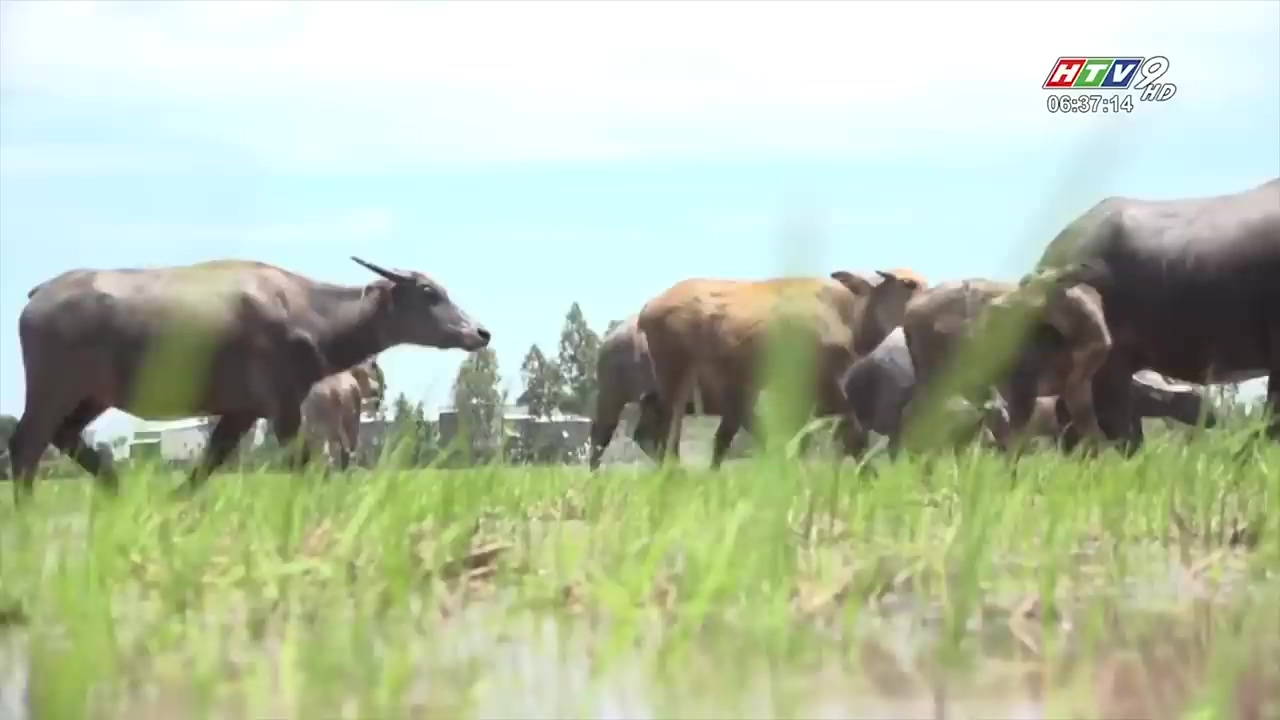

02. L21_V001 | frame 12450 | t=415.00s
    final=0.6430 | vlm=8.0 | err=None | caption=


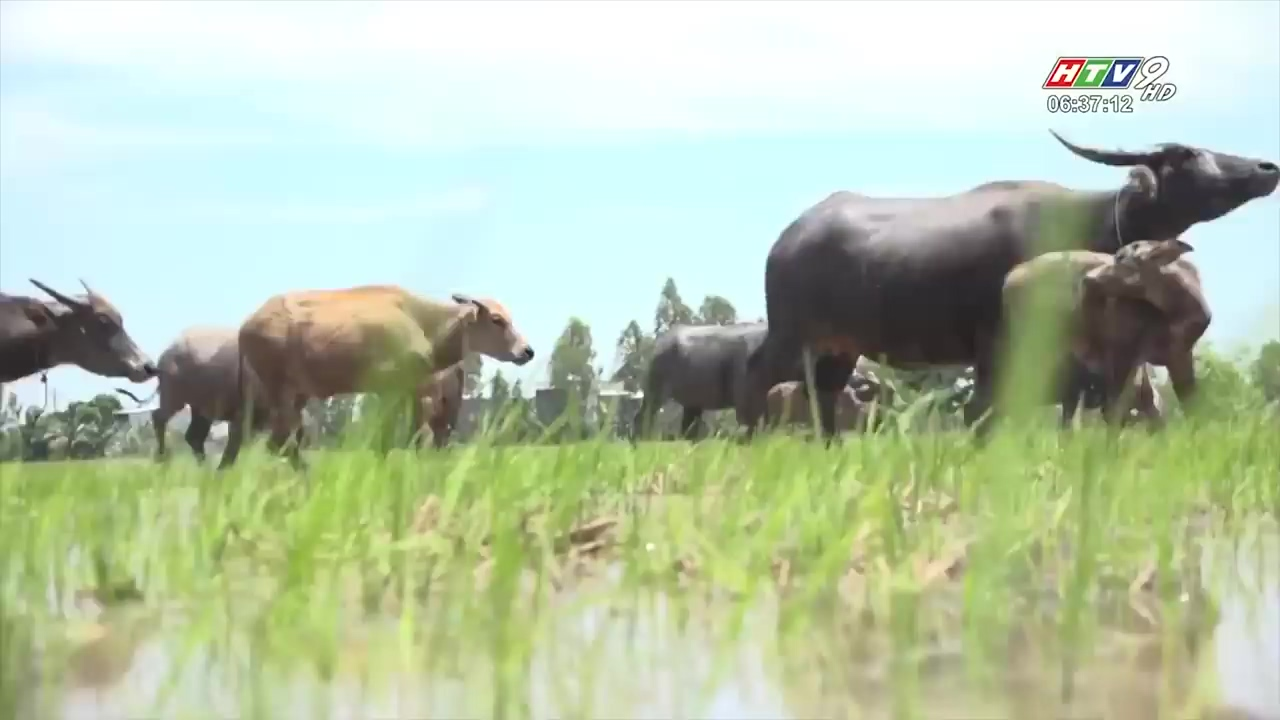

03. L28_V009 | frame 5805 | t=232.20s
    final=0.6054 | vlm=None | err=image_not_found | caption=there are many pink flamingos in the water near a rice field. main object: mountain (green color); action: bathing; setting: outdoor; location: in field
    [no local image]
04. L29_V018 | frame 25161 | t=1006.44s
    final=0.5808 | vlm=None | err=image_not_found | caption=there is a cow that is standing in the dirt by the water. main object: boat (brown color); action: moving; setting: outdoor; location: in swamp
    [no local image]
05. L28_V009 | frame 4320 | t=172.80s
    final=0.5685 | vlm=None | err=image_not_found | caption=there are many animals that are grazing in the field together. main object: cows (brown color); action: grazing; setting: outdoor; location: farm
    [no local image]
06. L28_V017 | frame 9720 | t=388.80s
    final=0.4977 | vlm=None | err=image_not_found | caption=there are some animals that are standing in the grass. main object: field (green color); action: gra

In [11]:
from IPython.display import Image as NotebookImage, display
import pandas as pd

from paths import video_image_dir

_pts_cache = {}

def frame_pts_time(video_id, frame_id):
    if video_id not in _pts_cache:
        _pts_cache[video_id] = pd.read_csv(MAPPING_DIR / f"{video_id}.csv")
    df = _pts_cache[video_id]
    rows = df[df["frame_idx"] == frame_id]
    if len(rows) == 0:
        return None
    return float(rows.iloc[0]["pts_time"])

def resolve_result_image(result):
    stored = result.get("image_path")
    if stored:
        candidate = Path(stored)
        if not candidate.is_absolute():
            candidate = KIS_ROOT / candidate
        if candidate.is_file():
            return candidate
    keyframe_n = result.get("keyframe_n")
    if keyframe_n is None:
        try:
            keyframe_n = object_lookup.get_keyframe_n(result["video_id"], result["frame_id"])
        except Exception:
            return None
    if keyframe_n is None:
        return None
    image_dir = video_image_dir(result["video_id"])
    for name in (f"{int(keyframe_n):03d}.jpg", f"{int(keyframe_n)}.jpg"):
        candidate = image_dir / name
        if candidate.is_file():
            return candidate
    return None

print("=== TOP 20 + ANH + LOCATION ===")
for rank, result in enumerate(final_ranked[:20], 1):
    video_id, frame_id = result["video_id"], result["frame_id"]
    pts = frame_pts_time(video_id, frame_id)
    location = f"{video_id} | frame {frame_id}" + (f" | t={pts:.2f}s" if pts is not None else " | t=?")
    print(f"{rank:02d}. {location}")
    print(f"    final={result.get('final_score', float('nan')):.4f} | vlm={result.get('vlm_raw_score')} | err={result.get('vlm_error')} | caption={(result.get('retrieval_text', '') or '')[:160]}")
    image_file = resolve_result_image(result)
    if image_file is not None:
        display(NotebookImage(filename=str(image_file), width=480))
    else:
        print("    [no local image]")


In [12]:
print("=== PRE-VLM vs POST-VLM (TOP 20 theo thu hang cuoi) ===")
ordered_pre = sorted(final_ranked, key=lambda r: r["score"], reverse=True)
pre_rank_of = {id(r): i for i, r in enumerate(ordered_pre, 1)}
for post, result in enumerate(final_ranked[:20], 1):
    pre = pre_rank_of[id(result)]
    delta = pre - post
    arrow = f"+{delta}" if delta > 0 else (str(delta) if delta < 0 else "=")
    video_id, frame_id = result["video_id"], result["frame_id"]
    pts = frame_pts_time(video_id, frame_id)
    loc = f"{video_id} f{frame_id}" + (f" t={pts:.1f}s" if pts is not None else "")
    print(f"post={post:02d} pre={pre:02d} ({arrow:>3}) | {loc} | pre={result['score']:.4f} -> final={result['final_score']:.4f} (vlm={result.get('vlm_raw_score')})") 


=== PRE-VLM vs POST-VLM (TOP 20 theo thu hang cuoi) ===
post=01 pre=04 ( +3) | L21_V001 f12510 t=417.0s | pre=0.5456 -> final=0.6819 (vlm=8.0)
post=02 pre=06 ( +4) | L21_V001 f12450 t=415.0s | pre=0.4900 -> final=0.6430 (vlm=8.0)
post=03 pre=01 ( -2) | L28_V009 f5805 t=232.2s | pre=0.6054 -> final=0.6054 (vlm=None)
post=04 pre=02 ( -2) | L29_V018 f25161 t=1006.4s | pre=0.5808 -> final=0.5808 (vlm=None)
post=05 pre=03 ( -2) | L28_V009 f4320 t=172.8s | pre=0.5685 -> final=0.5685 (vlm=None)
post=06 pre=05 ( -1) | L28_V017 f9720 t=388.8s | pre=0.4977 -> final=0.4977 (vlm=None)
post=07 pre=07 (  =) | L28_V010 f15525 t=621.0s | pre=0.4644 -> final=0.4644 (vlm=None)
post=08 pre=08 (  =) | L28_V011 f1485 t=59.4s | pre=0.4492 -> final=0.4492 (vlm=None)
post=09 pre=09 (  =) | L28_V003 f19980 t=799.2s | pre=0.4447 -> final=0.4447 (vlm=None)
post=10 pre=10 (  =) | L28_V010 f25020 t=1000.8s | pre=0.4383 -> final=0.4383 (vlm=None)
post=11 pre=11 (  =) | L28_V017 f9668 t=386.7s | pre=0.4130 -> final=

In [13]:
csv_output_dir = Path.home() / "Downloads"
if not csv_output_dir.is_dir():
    csv_output_dir = Path.home()

query_id = safe_filename_component(structured_query.get("query_id", "query"))
csv_output_path = csv_output_dir / f"{query_id}-kis.csv"

with csv_output_path.open(
    "w",
    encoding="utf-8",
    newline=""
 ) as csv_file:
    writer = csv.writer(csv_file, lineterminator="\n")
    for result in final_ranked[:100]:
        writer.writerow([result["video_id"], result["frame_id"]])

print(f"Saved results to {csv_output_path}")


Saved results to C:\Users\Khanh\Downloads\q_001-kis.csv
